In [1]:
from operator import add
from typing import Annotated, Any, TypedDict
from IPython.display import display, Image

from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import AIMessage, AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph, MessagesState
import mlflow

load_dotenv()

/Users/mori/dev/ai-agent-design-pattern/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [2]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("ReActエージェント")
mlflow.langchain.autolog()

In [3]:
tavily_search = TavilySearchResults(max_results=3)

@tool
def web_search(search_query: str) -> list[str]:
    """クエリの内容に応じて、web検索を行う関数

    Args:
        search_query: ユーザーからの検索クエリ
    Returns:
        検索結果のリスト
    """
    results = tavily_search.invoke(search_query)

    # 結果を整形
    results_formatted = []
    for result in results:
        title = result.get("title", "No Title")
        content = result.get("content", "No Content")
        results_formatted.append(f"タイトル：{title}\n\nコンテンツ：{content}")

    return results_formatted

tools = [web_search]
tools_by_name = {tool.name: tool for tool in tools}

/var/folders/mx/r5dnnbr55_b4_pyzp04zlqtm0000gn/T/ipykernel_34554/2275706503.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=3)


In [4]:

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)
llm_with_tools = llm.bind_tools(tools)



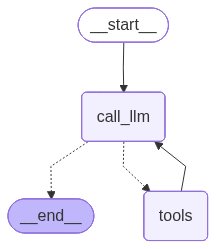

In [5]:
def node_call_llm(state: MessagesState):
    """LLMを呼び出すノード"""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


def node_route(state: MessagesState):
    """次のノードをルーティングするノード"""
    if len(state["messages"]) > 6:
        return END

    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"

    return END


def node_tools(state: MessagesState):
    """ツール呼び出しを実行するノード"""
    last_message = state["messages"][-1]

    tool_messages = []
    for tool_call in getattr(last_message, "tool_calls", []):
        tool_name = tool_call.get("name")
        tool = tools_by_name.get(tool_name)
        if tool is None:
            continue

        args = tool_call.get("args", {}) or {}
        tool_result = tool.invoke(args)

        tool_messages.append(
            ToolMessage(
                content=str(tool_result),
                name=tool_name,
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": tool_messages}


builder = StateGraph(MessagesState)
builder.add_node("call_llm", node_call_llm)
builder.add_node("tools", node_tools)

builder.add_edge(START, "call_llm")
builder.add_conditional_edges(
    "call_llm",
    node_route,
    {"tools": "tools", END: END},
)
builder.add_edge("tools", "call_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



In [6]:
system_prompt = """
あなたは、ユーザーの旅行予定をもとに、観光計画を立案するAIエージェントです。
以下のフローに従って、観光計画を立案してください。

## フロー
1. ユーザーからの旅行予定を受け取る
2. 旅行予定に基づいて、必要な情報をweb検索する
3. 旅行予定とweb検索の結果をもとに、観光計画を立案する
4. もし、ユーザーからの質問に答えるために必要な情報が不足している場合は、再度web検索を行う

## 注意点
- ユーザーの旅行予定が曖昧でも、聞き返さずに観光計画を立案する
- 必ずweb検索を行い、自分の知識だけに頼らずに観光計画を立案する
- 最低2回はweb検索を行う
"""
messages = [SystemMessage(content=system_prompt), HumanMessage(content="4月頭の奄美大島の三泊旅行に行きます。特産品だけでなく、穴場スポットなども知りたいです。")]

res = graph.invoke({"messages": messages})

for message in res["messages"]:
    message.pretty_print()

================================ System Message ================================


あなたは、ユーザーの旅行予定をもとに、観光計画を立案するAIエージェントです。
以下のフローに従って、観光計画を立案してください。

## フロー
1. ユーザーからの旅行予定を受け取る
2. 旅行予定に基づいて、必要な情報をweb検索する
3. 旅行予定とweb検索の結果をもとに、観光計画を立案する
4. もし、ユーザーからの質問に答えるために必要な情報が不足している場合は、再度web検索を行う

## 注意点
- ユーザーの旅行予定が曖昧でも、聞き返さずに観光計画を立案する
- 必ずweb検索を行い、自分の知識だけに頼らずに観光計画を立案する
- 最低2回はweb検索を行う

================================ Human Message =================================

4月頭の奄美大島の三泊旅行に行きます。特産品だけでなく、穴場スポットなども知りたいです。
================================== Ai Message ==================================

かしこまりました。4月頭の奄美大島へのご旅行、楽しみですね！
特産品や穴場スポットを含めた観光計画をご提案します。

まずは、奄美大島の基本的な情報と、4月におすすめのイベントやアクティビティについて調べてみます。
Tool Calls:
  web_search (c309c59f-fafb-475f-ac3d-0bbf92017f79)
 Call ID: c309c59f-fafb-475f-ac3d-0bbf92017f79
  Args:
    search_query: 奄美大島 4月 おすすめ イベント アクティビティ
  web_search (d8761cad-4dab-4acd-8f26-896a01992153)
 Call ID: d8761cad-4dab-4acd-8f26-896a01992153
  Args:
    search_query: 奄美大島 特産品 人気
======